In [38]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from kneed import KneeLocator  # pip install kneed

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [39]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 7.53 GB, difference +2.20 GB
CPU times: user 12.5 s, sys: 2.88 s, total: 15.3 s
Wall time: 17.1 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [40]:
npath = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_linear.csv"
node_df = pd.read_csv(npath)

print(node_df.head())

   bin_name chrom  bin_start    bin_end  global_hge_linear_unweighted
0  chr9:121     9  121000000  122000000                      0.000455
1  chr19:26    19   26000000   27000000                      0.000413
2  chr4:127     4  127000000  128000000                      0.000476
3  chr10:57    10   57000000   58000000                      0.000380
4   chr12:8    12    8000000    9000000                      0.000444


In [41]:
# filter
H = adata.X.tocsr().astype(float)
print(f"raw shape = {H.shape}")

raw shape = (2579, 2756467)


In [42]:
# IQR filter on locus degree (rows)
s = np.asarray(H.sum(axis=1)).ravel()
q1, q3 = np.quantile(s, [0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
row_mask = (s >= low) & (s <= high)

H = H[row_mask, :]
obs_idx = np.where(row_mask)[0] 

In [43]:
# drop singletons (reads with < 2 loci after row filter)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums >= 2
H = H[:, col_mask]
var_idx = np.where(col_mask)[0]          # maps H cols -> adata.var cols

In [44]:
# drop large hyperedges (reads with > 10 loci)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums <= 10
H = H[:, col_mask]
var_idx = var_idx[col_mask]

print(f"filtered shape = {H.shape}")

filtered shape = (2335, 2039865)


In [45]:
print(f"filtered shape = {H.shape}")
print(f"node_df rows: {len(node_df)}  (should equal H rows: {H.shape[0]})")
assert len(node_df) == H.shape[0], "Mismatch: check that node_df was built from the same obs_idx filter"

filtered shape = (2335, 2039865)
node_df rows: 2335  (should equal H rows: 2335)


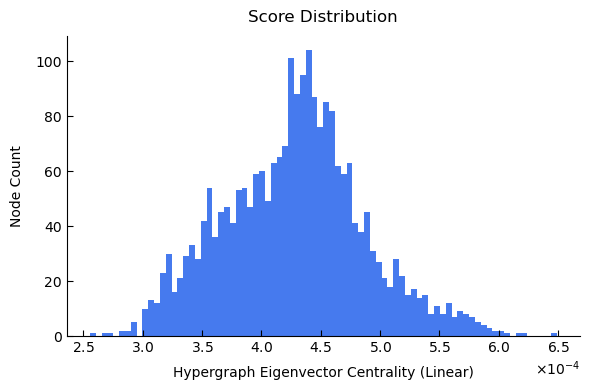

In [46]:
scores = node_df["global_hge_linear_unweighted"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)

ax.set_xlabel("Hypergraph Eigenvector Centrality (Linear)", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.show()

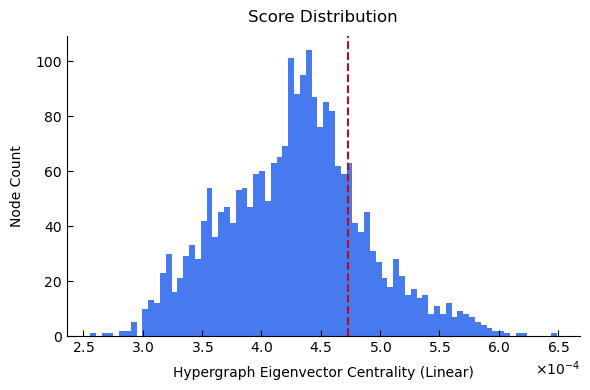

In [47]:
p20 = node_df["global_hge_linear_unweighted"].quantile(0.80)

scores = node_df["global_hge_linear_unweighted"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)
ax.axvline(p20, color="#B40F20", linestyle="--", label=f"top 10% threshold")

ax.set_xlabel("Hypergraph Eigenvector Centrality (Linear)", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


plt.savefig("score_dist_linear.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

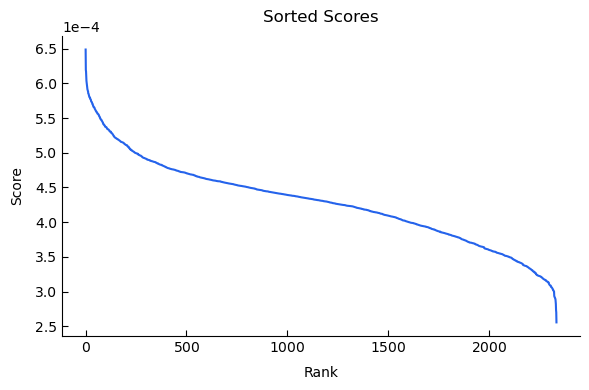

In [48]:
sorted_scores = np.sort(scores)[::-1]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(sorted_scores, lw=1.5, color="#2563eb")

ax.set_xlabel("Rank", labelpad=8)
ax.set_ylabel("Score", labelpad=8)
ax.set_title("Sorted Scores", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.tight_layout()
plt.show()

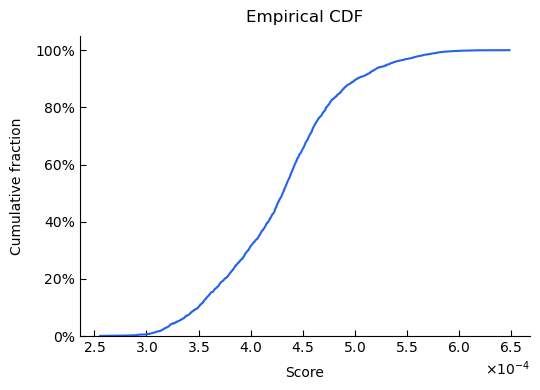

In [49]:
ecdf_x = np.sort(scores)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(ecdf_x, ecdf_y, lw=1.5, color="#2563eb")

ax.set_xlabel("Score", labelpad=8)
ax.set_ylabel("Cumulative fraction", labelpad=8)
ax.set_title("Empirical CDF", pad=10, loc="center")

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("ecdf_scores_linear.pdf", bbox_inches="tight")
plt.show()

In [50]:
z_scores = (scores - scores.mean()) / scores.std()

print("\nThreshold options & nodes selected:")
thresholds = {
    "Top 1%  (percentile)":    np.percentile(scores, 99),
    "Top 5%  (percentile)":    np.percentile(scores, 95),
    "Top 10% (percentile)":    np.percentile(scores, 90),
    "Top 20% (percentile)":    np.percentile(scores, 80),
    "Z-score > 2":             scores.mean() + 2 * scores.std(),
    "Z-score > 1.5":           scores.mean() + 1.5 * scores.std(),
    "IQR outliers (Q3+1.5IQR)":np.percentile(scores, 75) + 1.5 * (np.percentile(scores, 75) - np.percentile(scores, 25)),
}


for label, thresh in thresholds.items():
    n = (scores >= thresh).sum()
    print(f"  {label:<35s}  cutoff={thresh:.7f}  → {n:7d} nodes  ({100*n/len(scores):.1f}%)")

# Kneedle elbow on sorted scores
try:
    kl = KneeLocator(np.arange(len(sorted_scores)), sorted_scores,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    knee_score = sorted_scores[knee_rank] if knee_rank is not None else None
    n_knee = (scores >= knee_score).sum() if knee_score is not None else None
    print(f"  {'Kneedle elbow':<35s}  cutoff={knee_score:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(scores):.1f}%)")
    thresholds["Kneedle elbow"] = knee_score
except Exception as e:
    print(f"  Kneedle failed: {e}")


Threshold options & nodes selected:
  Top 1%  (percentile)                 cutoff=0.0005773  →      24 nodes  (1.0%)
  Top 5%  (percentile)                 cutoff=0.0005323  →     117 nodes  (5.0%)
  Top 10% (percentile)                 cutoff=0.0005023  →     234 nodes  (10.0%)
  Top 20% (percentile)                 cutoff=0.0004729  →     467 nodes  (20.0%)
  Z-score > 2                          cutoff=0.0005472  →      79 nodes  (3.4%)
  Z-score > 1.5                        cutoff=0.0005175  →     170 nodes  (7.3%)
  IQR outliers (Q3+1.5IQR)             cutoff=0.0005786  →      23 nodes  (1.0%)
  Kneedle elbow                        cutoff=0.0004898  →     311 nodes  (13.3%)


## Define Core Nodes

In [51]:
THRESHOLD_LABEL =  "Kneedle elbow"
THRESHOLD = thresholds[THRESHOLD_LABEL]

core_node_mask = scores >= THRESHOLD
node_df["is_core"] = core_node_mask

CN = node_df[core_node_mask].copy().reset_index(drop=True)

print(f"Threshold ({THRESHOLD_LABEL}): {THRESHOLD:.6f}")
print(f"Core nodes (CN): {len(CN)} / {len(node_df)}  ({100*len(CN)/len(node_df):.1f}%)")
CN.head()

Threshold (Kneedle elbow): 0.000490
Core nodes (CN): 311 / 2335  (13.3%)


,bin_name,chrom,bin_start,bin_end,global_hge_linear_unweighted,is_core
0,chr11:119,11,119000000,120000000,0.000499,True
1,chr3:34,3,34000000,35000000,0.000559,True
2,chr3:153,3,153000000,154000000,0.000531,True
3,chr6:93,6,93000000,94000000,0.000585,True
4,chr3:94,3,94000000,95000000,0.000555,True


## Define Core Edges

In [52]:
# Build H submatrix restricted to CN rows
cn_row_positions = np.where(core_node_mask)[0]   # positions in filtered H

H_cn = H[cn_row_positions, :]                    # (|CN| × n_hyperedges)

# A core edge must contain ONLY CN nodes:
#   total contacts in hyperedge == contacts from CN nodes only
total_contacts = np.asarray(H.sum(axis=0)).ravel()   # all nodes
cn_contacts    = np.asarray(H_cn.sum(axis=0)).ravel()  # CN nodes only

only_cn_mask = (cn_contacts == total_contacts) & (total_contacts > 0)

In [53]:
# "At least 1 expressed gene" filter
# adata.var['n_genes'] counts gene-overlapping alignments per read/hyperedge
#var_sub = adata.var.iloc[var_idx].copy()          # var rows matching filtered H cols

#has_gene_mask = var_sub["n_genes"].values >= 1    # at least 1 annotated gene

In [54]:
# Combined CE mask
ce_mask = only_cn_mask

CE_var_positions = np.where(ce_mask)[0]           # positions in filtered H cols
CE_adata_var_idx = var_idx[CE_var_positions]      # original adata.var indices

CE = adata.var.iloc[CE_adata_var_idx].copy().reset_index(drop=True)

print(f"\nHyperedge filtering summary:")
print(f"  Total filtered hyperedges:       {H.shape[1]:>8,}")
print(f"  Contain only CN nodes:           {only_cn_mask.sum():>8,}  ({100*only_cn_mask.sum()/H.shape[1]:.1f}%)")
print(f"  + Have ≥1 gene (CE):             {ce_mask.sum():>8,}  ({100*ce_mask.sum()/H.shape[1]:.1f}%)")
print(f"\nCore edges (CE): {len(CE)}")
CE.head()


Hyperedge filtering summary:
  Total filtered hyperedges:       2,039,865
  Contain only CN nodes:             42,262  (2.1%)
  + Have ≥1 gene (CE):               42,262  (2.1%)

Core edges (CE): 42262


,read_index,basename,mean_mapq,median_mapq,n_chromosomes,order,n_bins,read_length_bp,genes,n_genes
0,9,batch03,24.750000,19.0,1,4,3,5261,Myo16;Shcbp1,2
1,32,batch04,40.333333,60.0,1,3,3,4715,Csmd1,1
2,254,batch01,60.000000,60.0,2,5,2,4239,Ccdc91;Auts2,2
3,316,batch03,60.000000,60.0,1,3,2,2978,,0
4,517,batch04,40.166667,60.0,2,6,3,3263,Gm45745;5830408C22Rik,2


In [55]:
CN.to_csv("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/linear/core_nodes.csv", index=False)
CE.to_csv("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/linear/core_edges.csv", index=False)

# Core submatrix
H_core = H[np.ix_(cn_row_positions, CE_var_positions)]
sp.save_npz("/scratch/indikar_root/indikar1/jduhamel/pore_c/centrality/linear/H_core.npz", H_core.tocsr())

print("Saved: core_nodes.csv, core_edges.csv, H_core.npz")
print(f"\nCore incidence matrix H_core shape: {H_core.shape}")
print(f"  rows = CN nodes, cols = CE hyperedges")
print(f"\nCN chromosomes:\n{CN['chrom'].value_counts().to_string()}")
print(f"\nCE gene summary:\n{CE[['n_genes','genes']].describe()}")

Saved: core_nodes.csv, core_edges.csv, H_core.npz

Core incidence matrix H_core shape: (311, 42262)
  rows = CN nodes, cols = CE hyperedges

CN chromosomes:
chrom
8     78
6     72
3     57
11    28
5     21
7     13
12     8
17     6
13     6
16     5
2      4
1      4
14     4
18     1
4      1
15     1
10     1
9      1

CE gene summary:
            n_genes
count  42262.000000
mean       1.639984
std        1.089317
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max       11.000000
